<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/fraud_detection_using_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best k: 2 (Silhouette: 0.836)


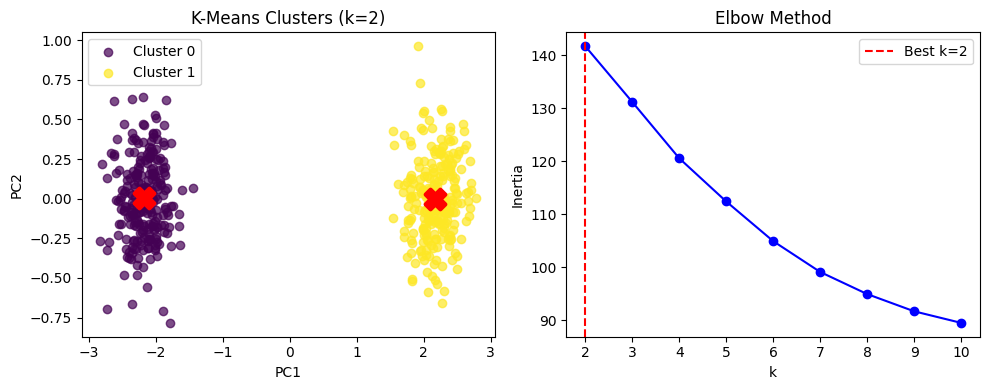

Silhouette Scores: {2: '0.836', 3: '0.492', 4: '0.265', 5: '0.255', 6: '0.141', 7: '0.139', 8: '0.141', 9: '0.145', 10: '0.146'}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, euclidean_distances
np.random.seed(42)

# TASK 1: Generate synthetic dataset (500 samples, 5 features, 2 distinct clusters)
n_samples = 500
X = np.concatenate([np.random.normal([2,2,2,2,2], 0.5, (250,5)),
                    np.random.normal([-2,-2,-2,-2,-2], 0.5, (250,5))])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TASK 2: K-Means from scratch implementation
class KMeansScratch:
    def __init__(self, n_clusters=5, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        # Random initialization
        idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[idx]

        for _ in range(self.max_iter):
            # Assignment step (calculate distances)
            distances = euclidean_distances(X, self.centroids)
            self.labels_ = np.argmin(distances, axis=1)

            # Update step (calculate centroids)
            new_centroids = np.array([X[self.labels_ == k].mean(0)
                                    if np.sum(self.labels_ == k) > 0 else self.centroids[k]
                                    for k in range(self.n_clusters)])

            if np.allclose(self.centroids, new_centroids, rtol=1e-5):
                break
            self.centroids = new_centroids

        self.inertia_ = np.sum((X - self.centroids[self.labels_])**2)
        return self

# TASK 3 & 4: Elbow + Silhouette evaluation (run 3 times, find best k)
sil_scores = {k: [] for k in range(2, 11)}
inertias = []

for k in range(2, 11):
    scores = []
    for seed in [42, 123, 456]:
        np.random.seed(seed)
        kmeans = KMeansScratch(n_clusters=k)
        kmeans.fit(X_scaled)
        scores.append(silhouette_score(X_scaled, kmeans.labels_))
    sil_scores[k] = np.mean(scores)
    inertias.append(kmeans.inertia_)

best_k = max(range(2, 11), key=lambda k: sil_scores[k])
print(f"Best k: {best_k} (Silhouette: {sil_scores[best_k]:.3f})")

# TASK 5: 2D scatter plot with clusters colored
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

np.random.seed(42)
kmeans_final = KMeansScratch(n_clusters=best_k)
kmeans_final.fit(X_scaled)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
colors = plt.cm.viridis(np.linspace(0, 1, best_k))
for i in range(best_k):
    plt.scatter(X_2d[kmeans_final.labels_ == i, 0],
                X_2d[kmeans_final.labels_ == i, 1],
                c=[colors[i]], label=f'Cluster {i}', alpha=0.7)
cent_2d = pca.transform(kmeans_final.centroids)
plt.scatter(cent_2d[:, 0], cent_2d[:, 1], c='red', marker='X', s=200, linewidths=3)
plt.title(f'K-Means Clusters (k={best_k})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), inertias, 'bo-')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()

print("Silhouette Scores:", {k: f"{v:.3f}" for k, v in sil_scores.items()})
